In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("../")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
import jax
from housemaze import utils
from housemaze.human_dyna import multitask_env as maze
from housemaze.human_dyna import mazes
from analysis import housemaze_utils
from analysis import data_loading
from experiment_utils import SuccessTrackingAutoResetWrapper

dummy_env_params = housemaze_utils.get_params(mazes.big_practice_maze)
dummy_rng = jax.random.PRNGKey(42)
task_runner = maze.TaskRunner(task_objects=housemaze_utils.task_objects)
base_env = maze.HouseMaze(
    task_runner=task_runner,
    num_categories=200,
)
web_env = SuccessTrackingAutoResetWrapper(base_env)
example_web_timestep = web_env.reset(dummy_rng, dummy_env_params)


No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


In [4]:
data_dir = '/Users/wilka/git/research/results/human_dyna/'
searches = {
    'Paths': f'{data_dir}/user_data/*exp4*/*v1*paths*.json',
    'Start': f'{data_dir}/user_data/*exp4*/*v1*start*.json',
    'Plan (Tell)': f'{data_dir}/user_data/*exp4*/*v1*r1-t0-plan*.json',
    "Plan (Don't Tell)": f'{data_dir}/user_data/*exp4*/*v1*r0-t0-plan*.json',
    'Shortcut': f'{data_dir}/user_data/*exp4*/*v1*shortcut*.json',
}

valid_files = data_loading.get_valid_files(searches)

Paths: 23/27 valid files
Start: 25/29 valid files
Plan (Tell): 24/38 valid files
Plan (Don't Tell): 24/35 valid files
Shortcut: 28/36 valid files


In [7]:
# TESTING
df, data = data_loading.make_episode_data(
    file=valid_files[0], example_timestep=example_web_timestep,
    overwrite_episode_info=True)
# df.filter(eval=True).head()

Filtered 46 data points


maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,new_path,old_path,user,exp,debug,version,tell_reuse,timer,reversal
str,i64,str,str,i64,i64,i64,bool,i64,i64,i64,i64,str,bool,bool,i64,i64,i64,i64,i64,i64,str
"""big_m3_maze1""",1,"""exp4-v1-r1-t0-paths""","""reusing longer of two paths wh…",3,16,1,true,13,0,2820177880,33,"""Female""",false,false,2820177880,4,0,1,1,0,"""F,T"""
"""big_m3_maze1""",1,"""exp4-v1-r1-t0-paths""","""reusing longer of two paths wh…",3,34,1,true,29,0,2820177880,33,"""Female""",false,false,2820177880,4,0,1,1,0,"""T,F"""
"""big_m3_maze1""",1,"""exp4-v1-r1-t0-paths""","""reusing longer of two paths wh…",3,52,1,true,31,0,2820177880,33,"""Female""",false,false,2820177880,4,0,1,1,0,"""T,T"""
"""big_m3_maze1""",1,"""exp4-v1-r1-t0-paths""","""reusing longer of two paths wh…",3,69,1,true,31,0,2820177880,33,"""Female""",false,false,2820177880,4,0,1,1,0,"""F,F"""


In [8]:
df = data_loading.make_all_episode_data(
    files=valid_files,
    example_timestep=example_web_timestep,
    overwrite_episode_info=True,
    # debug=True
)
df.head()

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


index,maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,new_path,old_path,user,exp,debug,version,tell_reuse,timer,reversal
u32,str,i64,str,str,i64,i64,i64,bool,i64,i64,i64,i64,str,bool,bool,i64,i64,i64,i64,i64,i64,str
0,"""big_m3_maze1""",0,"""exp4-v1-r1-t0-paths""","""reusing longer of two paths wh…",3,0,1,false,29,0,2820177880,33,"""Female""",false,false,2820177880,4,0,1,1,0,"""F,T"""
1,"""big_m3_maze1""",0,"""exp4-v1-r1-t0-paths""","""reusing longer of two paths wh…",3,1,2,false,29,0,2820177880,33,"""Female""",false,false,2820177880,4,0,1,1,0,"""F,T"""
2,"""big_m3_maze1""",0,"""exp4-v1-r1-t0-paths""","""reusing longer of two paths wh…",3,2,3,false,29,0,2820177880,33,"""Female""",false,false,2820177880,4,0,1,1,0,"""F,T"""
3,"""big_m3_maze1""",0,"""exp4-v1-r1-t0-paths""","""reusing longer of two paths wh…",3,3,4,false,31,1,2820177880,33,"""Female""",false,false,2820177880,4,0,1,1,0,"""F,T"""
4,"""big_m3_maze1""",0,"""exp4-v1-r1-t0-paths""","""reusing longer of two paths wh…",3,4,5,false,29,0,2820177880,33,"""Female""",false,false,2820177880,4,0,1,1,0,"""F,T"""


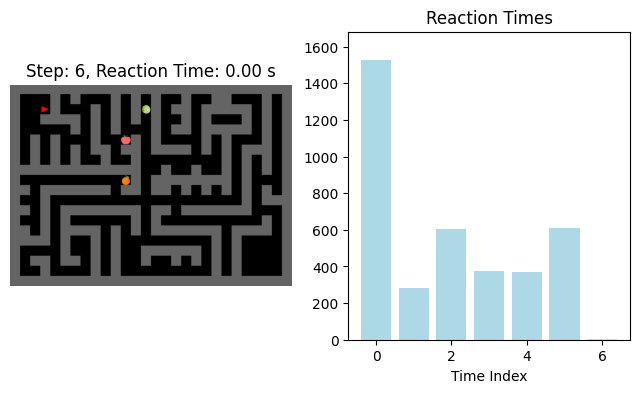

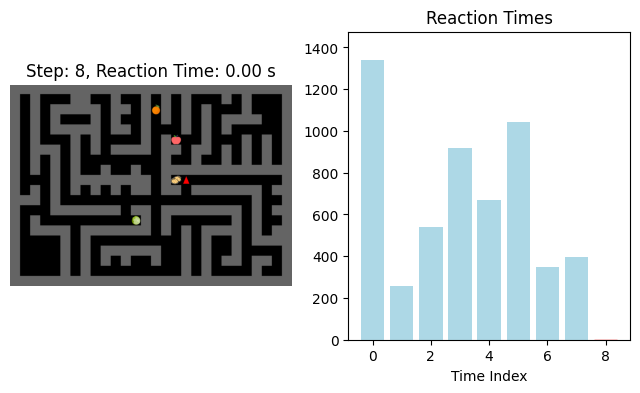

In [10]:
users_unreliable = [
    724250996,
    560893899,
    1364102698
]
user = users_unreliable[-1]
# user = 560893899
# new = df.filter(user=user, eval=False)
# housemaze_utils.create_episode_reaction_times_video(new.episodes[0])

new = df.filter(user=user, eval=True)
housemaze_utils.create_episode_reaction_times_video(new.episodes[0])
housemaze_utils.create_episode_reaction_times_video(new.episodes[1])

In [12]:
df.filter(user=user, eval=True).head()

index,maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,new_path,old_path,user,exp,debug,version,tell_reuse,timer,reversal
u32,str,i64,str,str,i64,i64,i64,bool,i64,i64,i64,i64,str,bool,bool,i64,i64,i64,i64,i64,i64,str
0,"""big_m4_maze_short_eval_diff""",2,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,51,1,true,13,0,1364102698,56,"""Male""",null,null,1364102698,4,0,1,0,0,"""F,F"""
1,"""big_m4_maze_short_eval_same_bl…",1,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,67,1,true,13,1,1364102698,56,"""Male""",null,null,1364102698,4,0,1,0,0,"""T,F"""
2,"""big_m4_maze_short_eval_same_bl…",1,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,96,1,true,46,1,1364102698,56,"""Male""",null,null,1364102698,4,0,1,0,0,"""T,T"""
3,"""big_m4_maze_short_eval_diff""",2,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,97,1,true,29,0,1364102698,56,"""Male""",null,null,1364102698,4,0,1,0,0,"""T,T"""
4,"""big_m4_maze_long_eval_same_bli…",1,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,149,1,true,29,0,1364102698,56,"""Male""",null,null,1364102698,4,0,1,0,0,"""F,F"""


No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 47 data points
Filtered 52 data points
Filtered 54 data points
Filtered 60 data points
Filtered 52 data points
Filtered 46 data points
Filtered 41 data points
Filtered 66 data points
Filtered 46 data points
Filtered 46 data points
Filtered 47 data points
Filtered 47 data points
Filtered 60 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 46 data points
Filtered 135 data points
Filtered 89 data points
Filtered 56 data points
Filtered 47 data points
Filtered 47 data points
Filtered 53 data points
Filtered 62 data points
Filtered 57 data points
Filtered 23 data points
Filtered 55 data points
Filtered 53 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 32 data p